# Imports 

In [3]:
import pandas as pd
import os
import re
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import numpy as np
import matplotlib.patches as mpatches

# Functions

# Datasets

In [4]:
path = "../../Data_Processing/outputs/banks_y9c"

In [7]:
df_9c = pd.concat(
    [
        pd.read_pickle(os.path.join(path, file))
        for file in os.listdir(path)
        # if "df_banks_part_" in file
    ],
    axis=0,
).reset_index(drop=True)

## Target variable definition

In [8]:
df_9c_sorted = df_9c[
    sorted(df_9c.columns, key=lambda c: (not c[0].islower(), c.lower(), c))
].sort_values(by=["id", "quarter"])

In [10]:
def value_x_quarters_before(
    df: pd.DataFrame, quarter: str, nr_quarters_before: int, value_col: str
):
    """
    Returns the values x quarters before a target quarter for any given column.

    Parameters:
        df (pd.DataFrame): DataFrame with columns ['id', 'year', 'nr_quarter', ...].
        quarter (str): Target quarter YYYYMMDD.
        nr_quarters_before (int): Number of quarters to go back.
        value_col (str): Name of the column to retrieve values for.

    Returns:
        pd.DataFrame: DataFrame with columns ['id', 'year', 'nr_quarter', f'{value_col}_x_quarters_before']
    """

    target_year = int(quarter[:4])
    target_month = int(quarter[4:6])
    target_quarter = ((target_month - 1) // 3) + 1

    # Compute the target quarter’s "absolute quarter number"
    target_abs_quarter = target_year * 4 + target_quarter

    # Compute the quarter to look for
    desired_abs_quarter = target_abs_quarter - nr_quarters_before

    # Convert abs_quarter back to year and quarter
    desired_year = desired_abs_quarter // 4
    desired_quarter = desired_abs_quarter % 4
    if desired_quarter == 0:
        desired_year -= 1
        desired_quarter = 4

    # Filter for desired quarter
    result = df[
        (df["year"] == desired_year) & (df["nr_quarter"] == desired_quarter)
    ].copy()

    return result[["id", "year", "nr_quarter", value_col]]

In [ ]:
selected_col = "TOTAL_ASSETS"
target_quarter = "20241231"
nr_quarters_before = 8

# Get the values x quarters before
df_value_x_quarters_before = value_x_quarters_before(
    df=df_9c_sorted,
    quarter=target_quarter,
    nr_quarters_before=nr_quarters_before,
    value_col=selected_col,
)


# Get target quarter values
df_target = df_9c_sorted[df_9c_sorted["quarter"] == target_quarter][
    ["id", "year", "nr_quarter", selected_col]
]

# Merge on 'id' so we can calculate ratio
df_merged = df_target.merge(
    df_value_x_quarters_before[["id", selected_col]],
    on="id",
    suffixes=("_target", f"_prev_{nr_quarters_before}_quarters"),
)

# Calculate ratio
df_merged[f"{selected_col}_growth_{nr_quarters_before}_quarters"] = (
    df_merged[f"{selected_col}_target"]
    / df_merged[f"{selected_col}_prev_{nr_quarters_before}_quarters"]
    - 1
)
df_merged[f"{selected_col}_growth_annualized"] = (
    1 + df_merged[f"{selected_col}_growth_{nr_quarters_before}_quarters"]
) ** (4 / nr_quarters_before) - 1

In [ ]:
df_filtered = df_merged[
    df_merged[f"{selected_col}_growth_annualized"].notnull()
    & np.isfinite(df_merged[f"{selected_col}_growth_annualized"])
]

<Axes: >

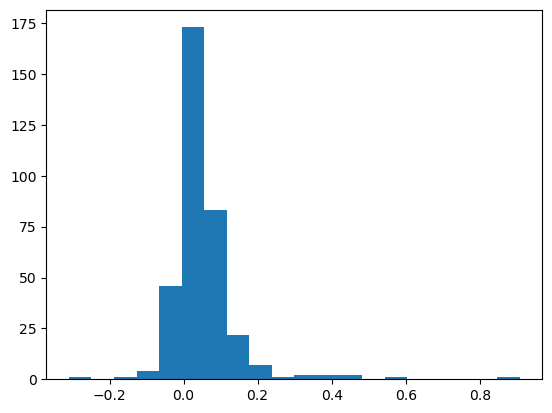

In [ ]:
df_filtered[df_filtered[f"{selected_col}_target"].fillna(0) != 0].sort_values(
    f"{selected_col}_growth_annualized"
).iloc[:, -1].hist(bins=20, grid=False)

<Axes: >

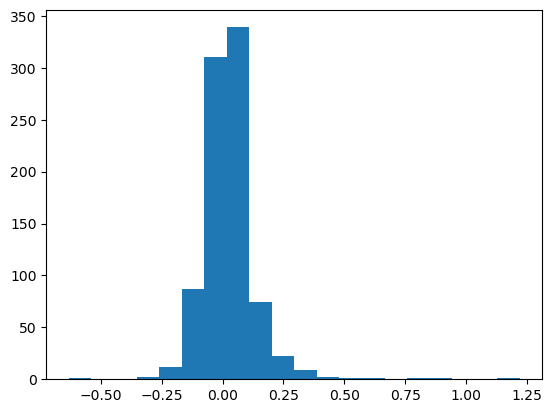

In [ ]:
df_filtered[df_filtered[f"{selected_col}_target"].fillna(0) != 0].sort_values(
    f"{selected_col}_growth_annualized"
).iloc[:, -1].hist(bins=20, grid=False)

## Estimate correlations

In [ ]:
cols_to_consider = [
    col for col in df_new.columns if ("CUMMULATIVE" not in col) and (col.upper() == col)
]


corr = df_new.loc[:, cols_to_consider].iloc[:, 4:].corr().stack().reset_index()
corr.columns = ["var1", "var2", "correlation"]

# Sort variable names in each pair to ignore order
corr[["var1", "var2"]] = corr[["var1", "var2"]].apply(
    lambda row: sorted(row), axis=1, result_type="expand"
)

# Drop duplicates (since now var1-var2 and var2-var1 are the same)
corr = corr.drop_duplicates()

# Remove self-correlations
corr = corr[corr["var1"] != corr["var2"]]

# Optional: filter by threshold
filtered = corr[corr["correlation"] > 0.8]

In [ ]:
corr.sort_values(by="correlation")

,var1,var2,correlation
124,ASSETS_INVESTMENT_NONBANKSUBSIDIARY_EQUITY_FRY9SP,NET_INCOME_FRY9LP,-0.318648
2195,ASSETS_INVESTMENT_BANK_SUBSIDIARY_EQUITY_FRY9SP,ASSETS_INVESTMENT_HOLDINGSUBSIDIARY_EQUITY_FRY9SP,-0.185029
104,ASSETS_CASH_FRY9SP,NET_INCOME_FRY9LP,-0.132359
118,ASSETS_INVESTMENT_BANK_SUBSIDIARY_EQUITY_FRY9SP,NET_INCOME_FRY9LP,-0.129370
134,ASSETS_OTHERASSETS_FRY9SP,NET_INCOME_FRY9LP,-0.126691
...,...,...,...
414,TOTAL_ASSETS_FRY9SP,TOTAL_EQUITY_FRY9SP,0.989986
4866,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
4795,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
4796,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,1.000000


In [ ]:
filtered.sort_values(by="correlation")

,var1,var2,correlation
2428,ASSETS_FEDERALFUNDS_RESELL_FRY9C,ASSETS_FIXEDASSETS_FRY9C,0.800185
562,ASSETS_OTHERASSETS_FRY9C,TOTAL_EQUITY_FRY9C,0.801931
4797,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,0.801949
4937,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,0.801949
1829,ASSETS_INVESTMENTS_SUBSIDIARIES_FRY9C,ASSETS_LOANSRECEIVABLES_INVESTMENT_FRY9C,0.802535
...,...,...,...
414,TOTAL_ASSETS_FRY9SP,TOTAL_EQUITY_FRY9SP,0.989986
4866,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
4795,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
504,ASSETS_TOTALASSETS_FRY9LP,TOTAL_ASSETS_FRY9LP,1.000000


In [ ]:
df.sort_values(by=["id", "quarter"])

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,year,month,nr_quarter
314775,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000331,85127.0,0.0,10360.0,11016.0,0.0,11016.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,3,1
308921,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000630,176673.0,0.0,24304.0,22079.0,0.0,22079.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,6,2
306773,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000930,272131.0,0.0,31624.0,33754.0,0.0,33754.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,9,3
300917,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20001231,368388.0,0.0,52966.0,45781.0,0.0,45781.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,12,4
298721,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20010331,94175.0,0.0,13907.0,11174.0,0.0,11174.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3740,6006899,UNITED STATES,"WINCHESTER BANCORP, MHC",20250630,0.0,0.0,0.0,0.0,-338.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3741,6007421,UNITED STATES,"WINCHESTER BANCORP, INC.",20250630,0.0,100.0,0.0,0.0,-615.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3742,6010430,UNITED STATES,LINDSEY FAMILY TRUST,20250630,0.0,0.0,0.0,0.0,212.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3743,6030278,UNITED STATES,FIRST SOUTHERN NATIONAL BANCSHARES INC,20250630,0.0,3000.0,0.0,0.0,11362.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
